# RiMEA 10: Route Allocation

This notebook uses the exported scenario archive [`scenarios/Rimea-10.zip`](scenarios/Rimea-10.zip) directly. The room-to-exit allocation is already encoded in the scenario journeys: rooms `1, 2, 3, 4, 7, 8, 9, 10` are assigned to the main exit, and the remaining rooms are assigned to the secondary exit.

The goal is to verify that every simulated person reaches the exit assigned by the scenario.


In [ ]:
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import pedpy
from shapely.geometry import Point, Polygon

from core.scenario import load_scenario, run_scenario


In [ ]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "font.size": 11,
    }
)

EXIT_COLORS = {
    "jps-exits_0": "#2563EB",
    "jps-exits_1": "#D97706",
}


## Load the Scenario and the Encoded Route Allocation


In [ ]:
SCENARIO_ZIP = Path("scenarios") / "Rimea-10.zip"

with zipfile.ZipFile(SCENARIO_ZIP) as zf:
    raw = json.loads(zf.read("config.json"))

scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())

journey_map = {journey["stages"][0]: journey["stages"][-1] for journey in raw["journeys"]}
journey_map


## Helper Functions

We identify each agent by its initial room polygon, then compare the assigned exit from the scenario journey with the exit closest to the agent's final recorded position.


In [ ]:
def agent_to_distribution(trajectory, distributions):
    first_positions = trajectory.data.sort_values(["id", "frame"]).groupby("id").first().reset_index()
    distribution_polygons = {key: Polygon(value["coordinates"]) for key, value in distributions.items()}
    mapping = {}
    for row in first_positions.itertuples():
        point = Point(row.x, row.y)
        for distribution_id, polygon in distribution_polygons.items():
            if polygon.covers(point):
                mapping[row.id] = distribution_id
                break
    return mapping


def agent_to_actual_exit(trajectory, exits):
    last_positions = trajectory.data.sort_values(["id", "frame"]).groupby("id").last().reset_index()
    exit_polygons = {key: Polygon(value["coordinates"]) for key, value in exits.items()}
    mapping = {}
    for row in last_positions.itertuples():
        point = Point(row.x, row.y)
        mapping[row.id] = min(
            exit_polygons,
            key=lambda exit_id: exit_polygons[exit_id].distance(point),
        )
    return mapping


def exit_measurement_lines(exits):
    lines = []
    for exit_id, exit_def in exits.items():
        coords = exit_def["coordinates"][:-1]
        xs = [xy[0] for xy in coords]
        ys = [xy[1] for xy in coords]
        if (max(xs) - min(xs)) >= (max(ys) - min(ys)):
            x = max(xs)
            lines.append((exit_id, pedpy.MeasurementLine([(x, min(ys)), (x, max(ys))])))
        else:
            y = max(ys)
            lines.append((exit_id, pedpy.MeasurementLine([(min(xs), y), (max(xs), y)])))
    return lines


## Run the Scenario


In [ ]:
%%capture
result = run_scenario(scenario, seed=42)
trajectory = pedpy.TrajectoryData(
    result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
    frame_rate=result.frame_rate,
)
walkable_area = pedpy.WalkableArea(scenario.walkable_polygon)

agent_distribution = agent_to_distribution(trajectory, raw["distributions"])
expected_exit = {agent_id: journey_map[distribution_id] for agent_id, distribution_id in agent_distribution.items()}
actual_exit = agent_to_actual_exit(trajectory, raw["exits"])
assignment_rows = [
    {
        "agent_id": agent_id,
        "distribution": agent_distribution[agent_id],
        "expected_exit": expected_exit[agent_id],
        "actual_exit": actual_exit[agent_id],
        "matches": expected_exit[agent_id] == actual_exit[agent_id],
    }
    for agent_id in sorted(expected_exit)
]


## Plot the Allocated Trajectories

Blue trajectories are assigned to the main exit, orange trajectories to the secondary exit. The white measurement lines mark the exit regions.


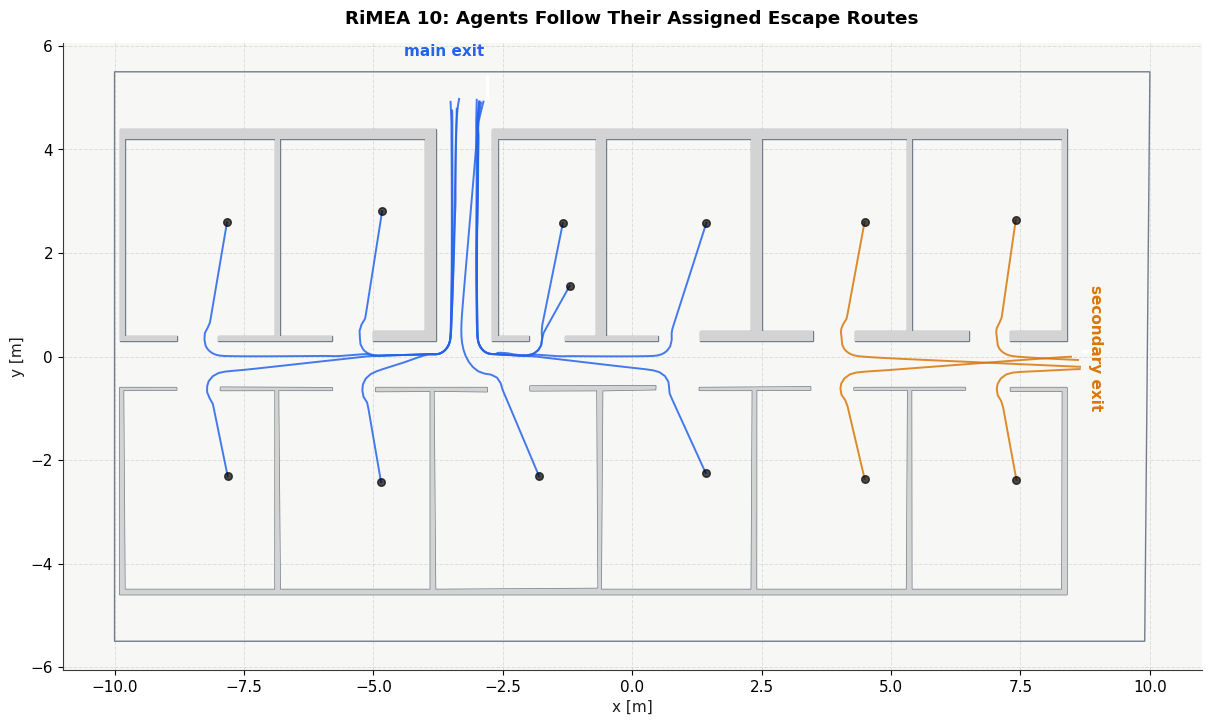

In [12]:
exit_lines = exit_measurement_lines(raw["exits"])

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
pedpy.plot_measurement_setup(
    walkable_area=walkable_area,
    measurement_lines=[line for _, line in exit_lines],
    axes=ax,
    ml_width=2.5,
    ml_alpha=0.7,
    ml_color="white",
).set_aspect("equal")

for exit_id in ["jps-exits_0", "jps-exits_1"]:
    agent_ids = [agent_id for agent_id, assigned_exit in expected_exit.items() if assigned_exit == exit_id]
    for agent_id in agent_ids:
        agent_traj = trajectory.data[trajectory.data["id"] == agent_id]
        ax.plot(
            agent_traj["x"],
            agent_traj["y"], 
            color=EXIT_COLORS[exit_id],
            linewidth=1.4,
            alpha=0.85,       
        )
first_frame = trajectory.data['frame'].min()
first_frame_data = trajectory.data[trajectory.data['frame'] == first_frame]
ax.scatter(first_frame_data['x'], first_frame_data['y'], 
          color='black', marker='o', s=30, alpha=0.7, zorder=5, label=f'Frame {first_frame}')

ax.text(-4.4, 5.8, "main exit", color=EXIT_COLORS["jps-exits_0"], fontsize=11, weight="bold")
ax.text(8.8, -1, "secondary exit", color=EXIT_COLORS["jps-exits_1"], fontsize=11, weight="bold", rotation=-90)
ax.set_title("RiMEA 10: Agents Follow Their Assigned Escape Routes", pad=14)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()


## Verify the Allocation


In [13]:
import pandas as pd
df = pd.DataFrame(assignment_rows)
print(df.to_string(index=False))

 agent_id         distribution expected_exit actual_exit  matches
        1  jps-distributions_0   jps-exits_0 jps-exits_0     True
        2  jps-distributions_1   jps-exits_0 jps-exits_0     True
        3  jps-distributions_2   jps-exits_0 jps-exits_0     True
        4  jps-distributions_3   jps-exits_0 jps-exits_0     True
        5  jps-distributions_4   jps-exits_0 jps-exits_0     True
        6  jps-distributions_5   jps-exits_0 jps-exits_0     True
        7  jps-distributions_6   jps-exits_0 jps-exits_0     True
        8  jps-distributions_7   jps-exits_0 jps-exits_0     True
        9  jps-distributions_7   jps-exits_0 jps-exits_0     True
       10  jps-distributions_8   jps-exits_1 jps-exits_1     True
       11  jps-distributions_9   jps-exits_1 jps-exits_1     True
       12 jps-distributions_10   jps-exits_1 jps-exits_1     True
       13 jps-distributions_11   jps-exits_1 jps-exits_1     True


In [14]:
mismatches = [row for row in assignment_rows if not row["matches"]]
print(f"All evacuated: {result.agents_remaining == 0}")
print(f"Mismatches: {len(mismatches)}")
assert result.agents_remaining == 0
assert not mismatches, mismatches

All evacuated: True
Mismatches: 0


In [ ]:
result.cleanup()